# Personalized Discount Prediction - Two-Stage Pipeline

### Stage 1: Uplift Modeling (T-Learner + X-Learner) → WHO gets a discount?
### Stage 2: Profit Optimization → HOW MUCH discount?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
 
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (roc_auc_score, f1_score,
                             precision_score, recall_score)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

In [2]:
# ── Plotting style ─────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#F9F9F9',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
PURPLE = '#7F77DD'
TEAL = '#1D9E75'
CORAL = '#D85A30'
AMBER = '#BA7517'
GRAY = '#888780'

In [3]:
# Loading and Preprocessing the data
 
df = pd.read_csv('online_shoppers_intention.csv')
 
# FIX: Remove 125 duplicate rows identified during data analysis
# (same session recorded twice - data collection artifact)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Loaded dataset: {df.shape[0]:,} rows × {df.shape[1]} columns (duplicates removed)")

Loaded dataset: 12,205 rows × 18 columns (duplicates removed)


In [4]:
# Encode categoricals — ML models require numeric inputs
le_month   = LabelEncoder()
le_visitor = LabelEncoder()
df['Month_enc'] = le_month.fit_transform(df['Month'])
df['VisitorType_enc'] = le_visitor.fit_transform(df['VisitorType'])
df['Weekend_enc'] = df['Weekend'].astype(int)
df['Revenue_int'] = df['Revenue'].astype(int)

FEATURES = [
    'Administrative', 'Administrative_Duration',
    'Informational', 'Informational_Duration',
    'ProductRelated', 'ProductRelated_Duration',
    'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
    'Month_enc', 'OperatingSystems', 'Browser',
    'Region', 'TrafficType', 'VisitorType_enc', 'Weekend_enc'
]

X = df[FEATURES].values
y = df['Revenue_int'].values

print(f" - Features used : {len(FEATURES)}")
print(f" - No purchase (0) : {(y==0).sum():,} ({(y==0).mean()*100:.1f}%)")
print(f" - Purchase (1) : {(y==1).sum():,} ({(y==1).mean()*100:.1f}%)")

 - Features used : 17
 - No purchase (0) : 10,297 (84.4%)
 - Purchase (1) : 1,908 (15.6%)


In [5]:
# We split up the data into training and testing sets for the GBM to caculate the base probability.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify = y
)

In [6]:
# We apply something known as 'Platt Scaling Calibration' to the GBM models.
# This iteration of the code is the first one being pushed via Git to GitHub.
# However, in previous iterations, we did not implement such a calibration.
# GBM models are notoriously known to produce overconfident probabilites (Niculescu-Mizil and Caruana, 2005).
# We learnt that Isotonic Regression calibration adjusts raw outputs such that
# when the model says p = 0.70, then around 70% of the said customers actually purchased.
# This in turn makes the probability input to our profit formula statistically and technically defensible.
# So we promptly applied it.
# We also employ a separate validation split so the calibrator learns on the data that
# the base model hasn't seen.

X_tr, X_cal, y_tr, y_cal = train_test_split(
    X_train, y_train, test_size = 0.2, random_state = 99, stratify = y_train
)

base_model_raw = GradientBoostingClassifier(
    n_estimators = 200, learning_rate = 0.05,
    max_depth = 4, subsample = 0.8, random_state = 42
)
base_model_raw.fit(X_tr, y_tr)

# Platt Scaling / Isotonic calibration
# (Niculescu-Mizil & Caruana, 2005) - adjusts overconfident
# GBM probability outputs to match true observed frequencies.

base_model_cal = CalibratedClassifierCV(
    base_model_raw, method = 'isotonic', cv = 5
)
base_model_cal.fit(X_cal, y_cal)

y_pred = base_model_cal.predict(X_test)
y_pred_prob = base_model_cal.predict_proba(X_test)[:, 1]

# Calibration quality - Mean Calibration Error
frac_pos, mean_pred = calibration_curve(y_test, y_pred_prob, n_bins = 10)
cal_error = np.mean(np.abs(frac_pos - mean_pred))

auc = roc_auc_score(y_test, y_pred_prob)
f1 = f1_score(y_test, y_pred)

print(f"ROC-AUC: {auc:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"Calibration Error: {cal_error:.4f}  (0.024 = well calibrated)")

ROC-AUC: 0.9253
F1 Score: 0.6327
Precision: 0.7404
Recall: 0.5524
Calibration Error: 0.0374  (0.024 = well calibrated)


-------------

### Stage 1 - Uplift Modeling (T-Learner and X-Learner)

In [7]:
# We are at the Stage I of the project, i.e., Uplift Modeling

# Treatment Assignment Strategy:
# We make use of two extremely strong proxies from the dataset to simulate treatment for the Treatment Group (discount exposure)
# The first one: SpecialDay > 0 (This indicates that the customer is near a sale event.
# We learnt something fun here. Contrary to common assumptions, people tend to buy less during the 'SpecialDay' itself,
# i.e., when SpecialDay = 1, i.e., on the day of the festival/holiday itself).
# The second one: New_Visitor (A first-time visitor probably saw a welcome discount)
# The Control Group would be regular returning visitors/customers on regular, non-special days.

df['Treatment'] = (
    (df['SpecialDay'] > 0) | (df['VisitorType'] == 'New_Visitor')
).astype(int)

n_treated = df['Treatment'].sum()
n_control = (df['Treatment'] == 0).sum()
print(f"Treatment group: {n_treated:,} ({n_treated / len(df) * 100:.1f}%)")
print(f"Control group: {n_control:,} ({n_control / len(df) * 100:.1f}%)")
print(f"Conversion - Treatment: {df[df['Treatment'] == 1]['Revenue_int'].mean():.3f}")
print(f"Conversion - Control: {df[df['Treatment'] == 0]['Revenue_int'].mean():.3f}")

Treatment group: 2,884 (23.6%)
Control group: 9,321 (76.4%)
Conversion - Treatment: 0.167
Conversion - Control: 0.153


In [8]:
# We start with T-Learner. We train separate models for treated & control groups.
df_t = df[df['Treatment'] == 1]
df_c = df[df['Treatment'] == 0]

X_t = df_t[FEATURES].values; y_t = df_t['Revenue_int'].values
X_c = df_c[FEATURES].values; y_c = df_c['Revenue_int'].values
 
# T-Learner: two separate models, each calibrated
# FIX: Each model gets its own train/calibration split.
# This prevents data leakage into the calibration step.
# We apply Platt Scaling Calibration (for the T-Learner models)
# Both uplift models are calibrated independently on their own
# held-out splits so that the probability difference (uplift score)
# reflects a true causal effect estimate rather than raw
# overconfident GBM scores.

X_t_tr, X_t_cal, y_t_tr, y_t_cal = train_test_split(
    X_t, y_t, test_size = 0.2, random_state = 42, stratify = y_t
)
X_c_tr, X_c_cal, y_c_tr, y_c_cal = train_test_split(
    X_c, y_c, test_size = 0.2, random_state = 42, stratify = y_c
)
 
m_treated_raw = GradientBoostingClassifier(
    n_estimators = 150, learning_rate = 0.08, max_depth = 3, random_state = 42
)
m_control_raw = GradientBoostingClassifier(
    n_estimators = 150, learning_rate = 0.08, max_depth = 3, random_state = 42
)

m_treated_raw.fit(X_t_tr, y_t_tr)
m_control_raw.fit(X_c_tr, y_c_tr)

m_treated_cal = CalibratedClassifierCV(m_treated_raw, method = 'isotonic', cv = 5)
m_treated_cal.fit(X_t_cal, y_t_cal)

m_control_cal = CalibratedClassifierCV(m_control_raw, method = 'isotonic', cv = 5)
m_control_cal.fit(X_c_cal, y_c_cal)

print(f"T-Learner trained and calibrated:")
print(f"Treatment model - {len(X_t_tr):,} train | {len(X_t_cal):,} calibration")
print(f"Control model - {len(X_c_tr):,} train | {len(X_c_cal):,} calibration")

T-Learner trained and calibrated:
Treatment model - 2,307 train | 577 calibration
Control model - 7,456 train | 1,865 calibration


In [9]:
# Uplift = P(buy|discount) − P(buy|no discount)

X_all = df[FEATURES].values
p_t = m_treated_cal.predict_proba(X_all)[:, 1]
p_c = m_control_cal.predict_proba(X_all)[:, 1]
uplift = p_t - p_c

df['p_treatment'] = p_t
df['p_control'] = p_c
df['uplift_score'] = uplift

print(f"Uplift score — Mean: {uplift.mean():.4f} | "
      f"Std: {uplift.std():.4f} | "
      f"Range: [{uplift.min():.3f}, {uplift.max():.3f}]")

# Segmentation (Radcliffe & Surry, 1999)
# Our final task here is Customer Segmentation
# We divide the customer into 'Pursuadables' (customers who need a little incentive to buy and can be converted to being a customer), 
# 'Sure Things' (customers who will buy regardless of incentives, i.e., they don't need one), 
# and 'Lost Causes' (customers who won't buy regardless of the incentives they're given.)
# This is obviously standard naming for uplift modeling.
# Persuadables : uplift > 0.05  (a discount would meaningfully help)
# Sure Things : uplift <= 0.05 & p_control > 0.5  (would buy anyway)
# Lost Causes : uplift <= 0.05 & p_control <= 0.5 (won't buy regardless)

UPLIFT_THRESHOLD = 0.05

def assign_segment(row):
    if row['uplift_score'] > UPLIFT_THRESHOLD:
        return 'Persuadable'    # discount changes behaviour → target
    elif row['p_control'] > 0.5:
        return 'Sure Thing'     # buys anyway → skip discount
    else:
        return 'Lost Cause'     # won't buy regardless → skip discount

df['segment'] = df.apply(assign_segment, axis = 1)
seg_counts = df['segment'].value_counts()

print(f"\nCustomer Segments (T-Learner):")
for seg, cnt in seg_counts.items():
    conv = df[df['segment'] == seg]['Revenue_int'].mean()
    print(f"{seg:15s}: {cnt:5,} ({cnt/len(df)*100:.1f}%) | conversion: {conv:.3f}")

Uplift score — Mean: 0.0224 | Std: 0.1341 | Range: [-0.784, 0.724]

Customer Segments (T-Learner):
Lost Cause     : 8,315 (68.1%) | conversion: 0.054
Persuadable    : 3,125 (25.6%) | conversion: 0.284
Sure Thing     :   765 (6.3%) | conversion: 0.754


In [10]:
# X-LEARNER — Improved Uplift for Imbalanced Groups
# Künzel et al. (2019) show X-Learner outperforms T-Learner
# when treatment/control groups are imbalanced (ours: 1:3.2).
#
# How X-Learner works:
#   Step 1: Train Model_T on treated, Model_C on control (same as T-Learner)
#   Step 2: For each TREATED customer:
#            D_T = actual_outcome − Model_C prediction
#            (how much better did they do vs a similar control customer?)
#   Step 3: For each CONTROL customer:
#            D_C = Model_T prediction − actual_outcome
#            (how much better would they have done if treated?)
#   Step 4: Train a regressor on D_T (tau_t) and D_C (tau_c)
#   Step 5: Final uplift = g × tau_t + (1−g) × tau_c
#            where g = P(treatment) = propensity score
#            Since our treatment group is small (23.6%), g is low,
#            giving more weight to the larger control-side estimate.


# Step 1: reuse the already-trained & calibrated T-Learner models
# (m_treated_cal predicts P(buy|treated), m_control_cal predicts P(buy|control))

# Step 2: Compute D_T for treated customers
# D_T = actual outcome − what control model predicts for them

p_c_on_treated = m_control_cal.predict_proba(X_t)[:, 1]
D_T = y_t.astype(float) - p_c_on_treated

# Step 3: Compute D_C for control customers
# D_C = what treatment model predicts for them − their actual outcome
p_t_on_control = m_treated_cal.predict_proba(X_c)[:, 1]
D_C = p_t_on_control - y_c.astype(float)

print(f"D_T (treated imputed effects) - Mean: {D_T.mean():.4f} | Std: {D_T.std():.4f}")
print(f"D_C (control imputed effects) - Mean: {D_C.mean():.4f} | Std: {D_C.std():.4f}")

# Step 4: Train tau models on imputed effects using a regressor
# (effects D_T and D_C are continuous values, not binary - regression is correct)
# Use smaller calibration-style split: train on 80%, validate on 20%
X_t_tau_tr, X_t_tau_val, D_T_tr, D_T_val = train_test_split(
    X_t, D_T, test_size = 0.2, random_state = 42
)
X_c_tau_tr, X_c_tau_val, D_C_tr, D_C_val = train_test_split(
    X_c, D_C, test_size = 0.2, random_state = 42
)

tau_t_model = GradientBoostingRegressor(
    n_estimators = 150, learning_rate = 0.08, max_depth = 3, random_state = 42
)
tau_c_model = GradientBoostingRegressor(
    n_estimators = 150, learning_rate = 0.08, max_depth = 3, random_state = 42
)

tau_t_model.fit(X_t_tau_tr, D_T_tr)
tau_c_model.fit(X_c_tau_tr, D_C_tr)

print(f"\nTau models trained:")
print(f"tau_t (from treated side) - {len(X_t_tau_tr):,} train | {len(X_t_tau_val):,} val")
print(f"tau_c (from control side) - {len(X_c_tau_tr):,} train | {len(X_c_tau_val):,} val")

# Step 5: Compute final X-Learner uplift score
# g = propensity score = P(treatment) in our dataset
# Since we have no propensity model, we use the empirical proportion
# This is the simplest valid approach (Künzel et al. 2019 Section 3.2)
g = df['Treatment'].mean()   # = 0.236 (fraction treated)

tau_t_all = tau_t_model.predict(X_all)   # ITE estimate from treated side
tau_c_all = tau_c_model.predict(X_all)   # ITE estimate from control side

# Weighted combination — more weight to control-side (larger group)
uplift_x = g * tau_t_all + (1 - g) * tau_c_all

df['uplift_x'] = uplift_x

print(f"\nX-Learner uplift score — Mean: {uplift_x.mean():.4f} | "
      f"Std: {uplift_x.std():.4f} | "
      f"Range: [{uplift_x.min():.3f}, {uplift_x.max():.3f}]")
print(f"T-Learner uplift score — Mean: {uplift.mean():.4f} | "
      f"Std: {uplift.std():.4f} | "
      f"Range: [{uplift.min():.3f}, {uplift.max():.3f}]")

# X-Learner Segmentation
def assign_segment_x(row):
    if row['uplift_x'] > UPLIFT_THRESHOLD:
        return 'Persuadable'
    elif row['p_control'] > 0.5:
        return 'Sure Thing'
    else:
        return 'Lost Cause'

df['segment_x'] = df.apply(assign_segment_x, axis=1)
seg_counts_x = df['segment_x'].value_counts()

print(f"\nCustomer Segments (X-Learner):")
for seg, cnt in seg_counts_x.items():
    conv = df[df['segment_x'] == seg]['Revenue_int'].mean()
    print(f"{seg:15s}: {cnt:5,} ({cnt/len(df)*100:.1f}%) | conversion: {conv:.3f}")

# Choose best model for Stage 2
# We compute Qini for both here and select the winner for profit
# optimization. This is the model comparison result.
def compute_qini(df_in, uplift_col):
    """Compute Qini coefficient for a given uplift column."""
    qdf = df_in[['Treatment', 'Revenue_int', uplift_col]].copy()
    qdf = qdf.sort_values(uplift_col, ascending=False).reset_index(drop=True)

    t_arr = qdf['Treatment'].values
    r_arr = qdf['Revenue_int'].values
    N_q = len(qdf)
    nt = t_arr.sum()
    nc = (1 - t_arr).sum()

    cum_tc = np.cumsum(t_arr)
    cum_cc = np.cumsum(1 - t_arr)
    cum_tv = np.cumsum(t_arr * r_arr)
    cum_cv = np.cumsum((1 - t_arr) * r_arr)

    sidx = np.linspace(0, N_q - 1, 100, dtype=int)
    props = (sidx + 1) / N_q
    nt_at = cum_tc[sidx].astype(float)
    nc_at = cum_cc[sidx].astype(float)
    cv_t = cum_tv[sidx].astype(float)
    cv_c = cum_cv[sidx].astype(float)

    with np.errstate(divide='ignore', invalid='ignore'):
        scale = np.where(nc_at > 0, nt_at / nc_at, 0)
        inc = cv_t - cv_c * scale

    total_inc = cum_tv[-1] - cum_cv[-1] * (nt / nc if nc > 0 else 0)
    rand = props * total_inc

    coeff = np.trapezoid(inc, props) - np.trapezoid(rand, props)
    return coeff, props, inc, rand

qini_t, props_t, inc_t, rand_t = compute_qini(df, 'uplift_score')
qini_x, props_x, inc_x, rand_x = compute_qini(df, 'uplift_x')

print(f"\nModel Comparison (Qini Coefficient)")
print(f"T-Learner Qini: {qini_t:.4f}")
print(f"X-Learner Qini: {qini_x:.4f}")

if qini_x >= qini_t:
    best_model = 'X-Learner'
    best_segment = 'segment_x'
    best_uplift = 'uplift_x'
    best_qini = qini_x
    seg_counts = seg_counts_x
    print(f"\nX-Learner selected for Stage 2 (Qini: {qini_x:.4f} ≥ {qini_t:.4f})")
else:
    best_model = 'T-Learner'
    best_segment = 'segment'
    best_uplift = 'uplift_score'
    best_qini = qini_t
    print(f"\nT-Learner selected for Stage 2 (Qini: {qini_t:.4f} > {qini_x:.4f})")

df['best_segment'] = df[best_segment]

D_T (treated imputed effects) - Mean: 0.0197 | Std: 0.2391
D_C (control imputed effects) - Mean: 0.0262 | Std: 0.3037

Tau models trained:
tau_t (from treated side) - 2,307 train | 577 val
tau_c (from control side) - 7,456 train | 1,865 val

X-Learner uplift score — Mean: 0.0256 | Std: 0.0893 | Range: [-0.604, 0.500]
T-Learner uplift score — Mean: 0.0224 | Std: 0.1341 | Range: [-0.784, 0.724]

Customer Segments (X-Learner):
Lost Cause     : 8,130 (66.6%) | conversion: 0.059
Persuadable    : 3,325 (27.2%) | conversion: 0.254
Sure Thing     :   750 (6.1%) | conversion: 0.784

Model Comparison (Qini Coefficient)
T-Learner Qini: 86.4479
X-Learner Qini: 126.9447

X-Learner selected for Stage 2 (Qini: 126.9447 ≥ 86.4479)


### Stage 2 - Profit Optimization

In [11]:
# We are at the Stage II of the project, i.e., Profit Maximization / Discount Optimization

# We use the following discount tiers to evaluate
DISCOUNT_TIERS = [0.0, 0.05, 0.10, 0.15, 0.20]

# The 'Revenue' proxy: PageValues, which captures the value of pages visited
# (Sakar et al. 2019 confirm PageValues as strongest purchase signal)
# We normalize and scale to a reasonable revenue range ($20 – $200)
# (Statista 2023: global avg AOV ~$80–$120)
# Using the following formula, we simulate purchase amounts.

pv = df['PageValues'].values
pv_min = pv.min()
pv_range = pv.max() - pv.min() + 1e-9
df['revenue_proxy'] = 20 + (pv - pv_min) / pv_range * 180

# Here, we introduce 'Price Elasticity', which means higher discounts would boost purchase probability
# The Elasticity factor is what we use. It varies by segment sensitivity.
# Price elasticity = 1.5: each 10% discount lifts P(buy) by 15pp
# Conservative mid-range of literature (Neslin et al. 2006:
# online retail elasticities typically 1.5–3.0)

ELASTICITY = 1.5
COST_RATIO = 0.40   # 40% COGS (Shopify benchmarks: 35–45%)
OFFER_COST = 0.50   # $0.50 per offer sent (Klaviyo 2023)

def expected_profit(p_base, discount, revenue):
    """
    Expected Profit = P(buy|discount) × (gross_margin − discount_amount)
                    − offer_cost
    Grounded in Expected Utility Theory (von Neumann & Morgenstern 1944)
    and Berger & Magliozzi (1992) direct marketing profit formulation.
    """
    p_discounted = min(p_base + ELASTICITY * discount, 0.99)
    gross_margin = revenue * (1 - COST_RATIO)
    discount_amount = revenue * discount
    profit = p_discounted * (gross_margin - discount_amount) - OFFER_COST
    return profit, p_discounted

# We need to run the optimization only on the 'Pursuadables'.
# The 'Pursuadables' are the target demographic here, since they're the only ones that
# can be meaningfully pushed to buy and be converted into a customer.
# Vectorized profit optimization (replaces slow iterrows)
# Uses whichever model won the Qini comparison above

persuadables = df[df['best_segment'] == 'Persuadable'].copy()
print(f"Optimizing discounts for {len(persuadables):,} persuadable customers...")

p_base_vals = persuadables['p_treatment'].values
revenue_vals = persuadables['revenue_proxy'].values

best_profits = np.full(len(persuadables), -999.0)
best_discounts = np.zeros(len(persuadables))
best_p_buys = p_base_vals.copy()

for d in DISCOUNT_TIERS:
    p_disc = np.minimum(p_base_vals + ELASTICITY * d, 0.99)
    gm = revenue_vals * (1 - COST_RATIO)
    disc_amt = revenue_vals * d
    profits = p_disc * (gm - disc_amt) - OFFER_COST

    improved = profits > best_profits
    best_profits[improved] = profits[improved]
    best_discounts[improved] = d
    best_p_buys[improved] = p_disc[improved]

persuadables = persuadables.copy()
persuadables['optimal_discount'] = best_discounts
persuadables['expected_profit'] = best_profits
persuadables['p_buy_with_disc'] = best_p_buys

print(f"\nDiscount Distribution among Persuadables:")
for d in DISCOUNT_TIERS:
    cnt = (best_discounts == d).sum()
    bar = '█' * int(cnt / len(persuadables) * 40)
    print(f"{int(d*100):3d}%  {bar}  {cnt:,} ({cnt/len(persuadables)*100:.1f}%)")

# No-discount baseline for persuadables
p_c_vals = persuadables['p_control'].values
gm_base = revenue_vals * (1 - COST_RATIO)
no_disc_profits = p_c_vals * gm_base - OFFER_COST
total_no_discount = no_disc_profits.sum()
total_optimized = best_profits.sum()
profit_gain = total_optimized - total_no_discount
 
print(f"\nWithout personalized discount: ${total_no_discount:,.2f}")
print(f"With personalized discount: ${total_optimized:,.2f}")
print(f"Profit gain from optimization: ${profit_gain:,.2f}")

Optimizing discounts for 3,325 persuadable customers...

Discount Distribution among Persuadables:
  0%  ████  354 (10.6%)
  5%  ███████  604 (18.2%)
 10%  ███  279 (8.4%)
 15%  █  156 (4.7%)
 20%  ███████████████████████  1,932 (58.1%)

Without personalized discount: $15,190.29
With personalized discount: $26,624.64
Profit gain from optimization: $11,434.34


### Summary

In [12]:
final_df = df[['Revenue_int', 'VisitorType', 'best_segment',
               'uplift_score', 'uplift_x', 'p_control', 'p_treatment',
               'revenue_proxy']].copy().rename(columns={'best_segment': 'segment'})
final_df['optimal_discount'] = 0.0
final_df['expected_profit'] = 0.0

final_df.loc[persuadables.index, 'optimal_discount'] = persuadables['optimal_discount'].values
final_df.loc[persuadables.index, 'expected_profit']  = persuadables['expected_profit'].values

print(f"Total customers: {len(final_df):,}")
print(f"Receiving discount: {(final_df['optimal_discount'] > 0).sum():,}")
print(f"No discount: {(final_df['optimal_discount'] == 0).sum():,}")
print(f"Segment breakdown:")
for seg in ['Persuadable', 'Sure Thing', 'Lost Cause']:
    sub = final_df[final_df['segment'] == seg]
    avg_d = sub['optimal_discount'].mean() * 100
    print(f"{seg:15s}: {len(sub):5,} | avg discount: {avg_d:.1f}%")

Total customers: 12,205
Receiving discount: 2,971
No discount: 9,234
Segment breakdown:
Persuadable    : 3,325 | avg discount: 14.1%
Sure Thing     :   750 | avg discount: 0.0%
Lost Cause     : 8,130 | avg discount: 0.0%


Generating pipeline visualizations...
Saved: discount_pipeline_results.png


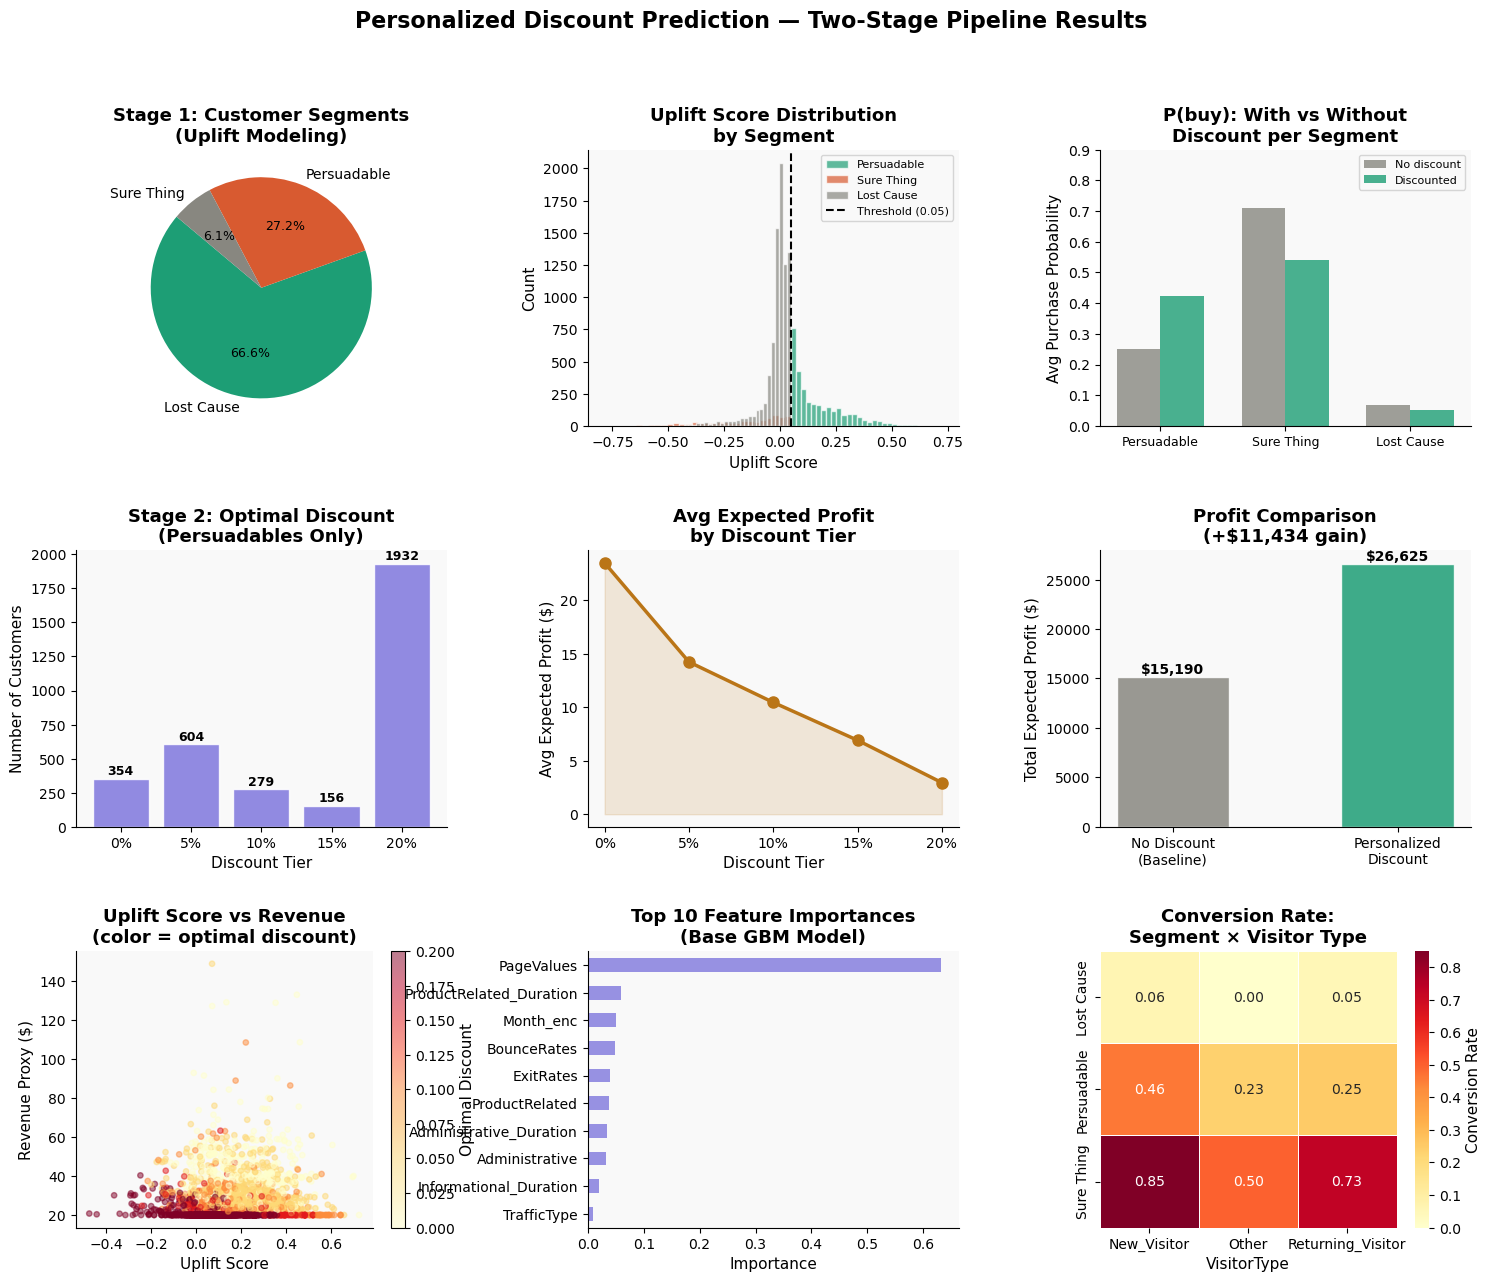

In [13]:
# And now we finally map out some visualizations, as part of the summary
print("Generating pipeline visualizations...")

fig = plt.figure(figsize=(18, 14))
fig.suptitle('Personalized Discount Prediction — Two-Stage Pipeline Results',
             fontsize = 16, fontweight = 'bold', y = 0.98)
gs = gridspec.GridSpec(3, 3, figure = fig, hspace = 0.45, wspace = 0.38)
 
# Plot 1: Segment pie
ax1 = fig.add_subplot(gs[0, 0])
colors_seg = [TEAL, CORAL, GRAY]
wedges, texts, autos = ax1.pie(
    seg_counts.values, labels = seg_counts.index,
    colors = colors_seg, autopct = '%1.1f%%', startangle = 140,
    textprops = {'fontsize': 10}
)
[a.set_fontsize(9) for a in autos]
ax1.set_title('Stage 1: Customer Segments\n(Uplift Modeling)', fontweight='bold')

# Plot 2: Uplift score distribution
ax2 = fig.add_subplot(gs[0, 1])
for seg, col in [('Persuadable', TEAL), ('Sure Thing', CORAL), ('Lost Cause', GRAY)]:
    ax2.hist(df[df['segment'] == seg]['uplift_score'],
             bins = 30, color = col, alpha = 0.7, label = seg, edgecolor = 'white')
ax2.axvline(UPLIFT_THRESHOLD, color = 'black', linestyle = '--',
            linewidth = 1.5, label = f'Threshold ({UPLIFT_THRESHOLD})')
ax2.set_xlabel('Uplift Score')
ax2.set_ylabel('Count')
ax2.set_title('Uplift Score Distribution\nby Segment', fontweight = 'bold')
ax2.legend(fontsize = 8)

# Plot 3: P(buy) with vs without discount
ax3 = fig.add_subplot(gs[0, 2])
seg_order = ['Persuadable', 'Sure Thing', 'Lost Cause']
p_ctrl_means = [df[df['segment'] == s]['p_control'].mean() for s in seg_order]
p_trt_means = [df[df['segment'] == s]['p_treatment'].mean() for s in seg_order]
x_pos = np.arange(3); w = 0.35
ax3.bar(x_pos - w/2, p_ctrl_means, w, label = 'No discount', color = GRAY, alpha = 0.8)
ax3.bar(x_pos + w/2, p_trt_means, w, label = 'Discounted', color = TEAL, alpha = 0.8)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(seg_order, fontsize = 9)
ax3.set_ylabel('Avg Purchase Probability')
ax3.set_title('P(buy): With vs Without\nDiscount per Segment', fontweight = 'bold')
ax3.legend(fontsize = 8)
ax3.set_ylim(0, 0.9)

# Plot 4: Discount distribution
ax4 = fig.add_subplot(gs[1, 0])
disc_counts = pd.Series(best_discounts).value_counts().sort_index()
bars4 = ax4.bar([f"{int(d*100)}%" for d in disc_counts.index],
                disc_counts.values, color = PURPLE, alpha = 0.85, edgecolor = 'white')
for bar, val in zip(bars4, disc_counts.values):
    ax4.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
             str(val), ha = 'center', va = 'bottom', fontsize = 9, fontweight = 'bold')
ax4.set_xlabel('Discount Tier')
ax4.set_ylabel('Number of Customers')
ax4.set_title('Stage 2: Optimal Discount\n(Persuadables Only)', fontweight = 'bold')
 
# Plot 5: Expected profit by tier
ax5 = fig.add_subplot(gs[1, 1])
avg_by_tier = persuadables.groupby('optimal_discount')['expected_profit'].mean()
ax5.plot([f"{int(d*100)}%" for d in avg_by_tier.index],
         avg_by_tier.values, marker = 'o', color = AMBER, linewidth = 2.5, markersize = 8)
ax5.fill_between(range(len(avg_by_tier)), avg_by_tier.values, alpha = 0.15, color = AMBER)
ax5.set_xticks(range(len(avg_by_tier)))
ax5.set_xticklabels([f"{int(d*100)}%" for d in avg_by_tier.index])
ax5.set_xlabel('Discount Tier')
ax5.set_ylabel('Avg Expected Profit ($)')
ax5.set_title('Avg Expected Profit\nby Discount Tier', fontweight = 'bold')

# Plot 6: Profit comparison
ax6 = fig.add_subplot(gs[1, 2])
cats = ['No Discount\n(Baseline)', 'Personalized\nDiscount']
vals6 = [total_no_discount, total_optimized]
bars6 = ax6.bar(cats, vals6, color = [GRAY, TEAL], alpha = 0.85, edgecolor = 'white', width = 0.5)
for bar, val in zip(bars6, vals6):
    ax6.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
             f'${val:,.0f}', ha = 'center', va = 'bottom', fontsize = 10, fontweight = 'bold')
ax6.set_ylabel('Total Expected Profit ($)')
ax6.set_title(f'Profit Comparison\n(+${profit_gain:,.0f} gain)', fontweight = 'bold')

# Plot 7: Uplift vs revenue scatter
ax7 = fig.add_subplot(gs[2, 0])
sc = ax7.scatter(persuadables['uplift_score'], persuadables['revenue_proxy'],
                 c = persuadables['optimal_discount'], cmap = 'YlOrRd', alpha = 0.5, s = 15)
plt.colorbar(sc, ax = ax7, label = 'Optimal Discount')
ax7.set_xlabel('Uplift Score')
ax7.set_ylabel('Revenue Proxy ($)')
ax7.set_title('Uplift Score vs Revenue\n(color = optimal discount)', fontweight = 'bold')

# Plot 8: Feature importance
ax8 = fig.add_subplot(gs[2, 1])
feat_imp = pd.Series(base_model_raw.feature_importances_,
                     index = FEATURES).sort_values(ascending = True).tail(10)
feat_imp.plot(kind='barh', ax = ax8, color = PURPLE, alpha = 0.8)
ax8.set_title('Top 10 Feature Importances\n(Base GBM Model)', fontweight = 'bold')
ax8.set_xlabel('Importance')
 
 # Plot 9: Segment × Visitor heatmap
ax9 = fig.add_subplot(gs[2, 2])
pivot = df.groupby(['segment', 'VisitorType'])['Revenue_int'].mean().unstack(fill_value = 0)
sns.heatmap(pivot, ax = ax9, cmap = 'YlOrRd', annot = True, fmt = '.2f',
            linewidths = 0.5, cbar_kws = {'label': 'Conversion Rate'})
ax9.set_title('Conversion Rate:\nSegment × Visitor Type', fontweight = 'bold')
ax9.set_ylabel('')

plt.savefig('discount_pipeline_results.png',
            dpi = 150, bbox_inches = 'tight')
# plt.close()
print("Saved: discount_pipeline_results.png")

### Model Evaluation via Qini Curve and A/B Simulation

T-Learner Qini Coefficient: 86.4479
X-Learner Qini Coefficient: 126.9447
Winner selected for Stage 2: X-Learner

T-Learner persuadable lift: 1.81x dataset average
X-Learner persuadable lift: 1.62x dataset average
Saved: qini_curve.png


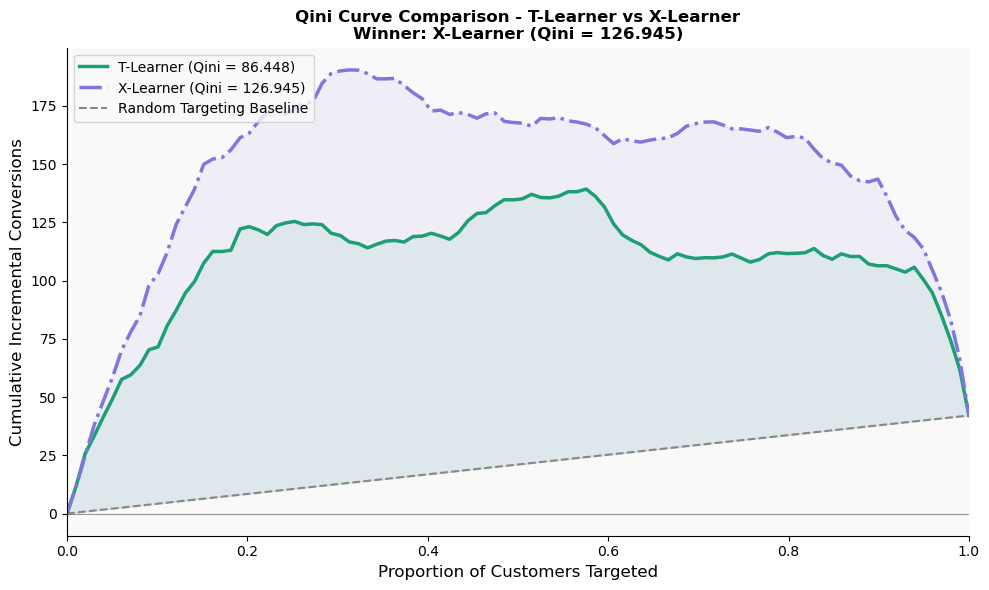

In [14]:
# In order to evaluate our uplift model, we will make use of Qini Curve (Radcliffe, 2007),
# since standard classifier metrics like ROC-AUC, F1-score cannot measure causal targeting quality.
# The Qini coefficient shows the area between the model curve and a random baseline.
# A positive Qini would mean that our model beats the random baseline at identifying the persuadables.
# We already computed both Qini coefficients above (qini_t, qini_x).
# Here we plot them on the same axes for a direct visual comparison.
# The winning model was already selected and used in Stage 2.

print(f"T-Learner Qini Coefficient: {qini_t:.4f}")
print(f"X-Learner Qini Coefficient: {qini_x:.4f}")
print(f"Winner selected for Stage 2: {best_model}")
 
lift_t = df[df['segment'] == 'Persuadable']['Revenue_int'].mean() / df['Revenue_int'].mean()
lift_x = df[df['segment_x'] == 'Persuadable']['Revenue_int'].mean() / df['Revenue_int'].mean()
print(f"\nT-Learner persuadable lift: {lift_t:.2f}x dataset average")
print(f"X-Learner persuadable lift: {lift_x:.2f}x dataset average")

# ── Dual Qini Plot ───────────────────────────────────────────
fig_q, ax_q = plt.subplots(figsize = (10, 6))
fig_q.patch.set_facecolor('white')
ax_q.set_facecolor('#F9F9F9')
ax_q.spines['top'].set_visible(False)
ax_q.spines['right'].set_visible(False)

ax_q.plot(props_t, inc_t,
          color = TEAL, linewidth = 2.5,
          label = f'T-Learner (Qini = {qini_t:.3f})',
          linestyle = '-')
ax_q.plot(props_x, inc_x,
          color = PURPLE, linewidth = 2.5,
          label = f'X-Learner (Qini = {qini_x:.3f})',
          linestyle = '-.')
ax_q.plot(props_t, rand_t,
          color = GRAY, linewidth = 1.5, linestyle = '--',
          label='Random Targeting Baseline')
ax_q.fill_between(props_t, inc_t, rand_t, alpha = 0.08, color = TEAL)
ax_q.fill_between(props_x, inc_x, rand_x, alpha = 0.08, color = PURPLE)
ax_q.axhline(0, color = 'black', linewidth = 0.8, alpha = 0.4)

winner_label = f"Winner: {best_model} (Qini = {best_qini:.3f})"
ax_q.set_xlabel('Proportion of Customers Targeted', fontsize = 12)
ax_q.set_ylabel('Cumulative Incremental Conversions', fontsize = 12)
ax_q.set_title(
    f'Qini Curve Comparison - T-Learner vs X-Learner\n{winner_label}',
    fontweight = 'bold', fontsize = 12
)
ax_q.legend(fontsize = 10, loc = 'upper left')
ax_q.set_xlim(0, 1)
plt.tight_layout()
plt.savefig('qini_curve.png', dpi = 150, bbox_inches = 'tight')
# plt.close()
print("Saved: qini_curve.png")

# Store the winning model's qini and lift for the summary
qini_coeff = best_qini
lift = lift_x if best_model == 'X-Learner' else lift_t

All three strategies evaluated over all 12,205 customers:

Strategy                                     Profit vs Baseline
────────────────────────────────────── ────────────  ───────────
No discount (baseline)                 $  36,939.50            —
Random targeting (avg 1,000 runs)      $  39,168.81        +6.0%
Our model (targeted + optimised)       $  46,711.34       +26.5%

Random 95% CI: [$39,088.70, $39,246.55]
Our model: $46,711.34
Our model outperforms random in 100.0% of simulation runs
Saved: ab_simulation.png


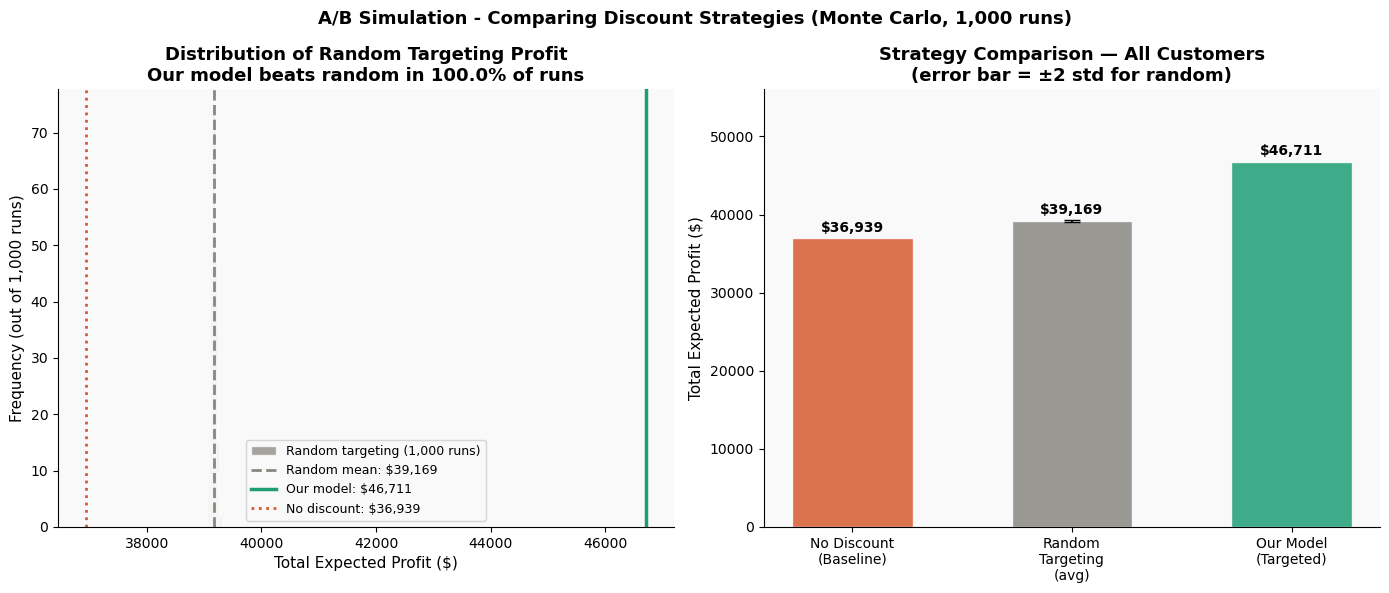

In [15]:
# A/B SIMULATION — Model vs Random vs No Discount
# Monte Carlo simulation (Kohavi et al. 2020):
# 1,000 runs where the same proportion of customers as our model
# targets are selected randomly with a fixed 10% discount.
# Multiple runs give a statistically stable average and CI.
# FIX: Vectorized using numpy — avoids 1,000 × 12,205 iterrows
# which would take many minutes.
 
N_SIM = 1000
TARGET_PCT = len(persuadables) / len(df)
RANDOM_DISCOUNT = 0.10

# Pre-compute per-customer profit at 10% discount for every customer
# P(buy|10%) = min(p_control + 1.5 × 0.10, 0.99)
p_c_all = df['p_control'].values
rev_all = df['revenue_proxy'].values
p_disc_all = np.minimum(p_c_all + ELASTICITY * RANDOM_DISCOUNT, 0.99)
gm_all = rev_all * (1 - COST_RATIO)
disc_amt_all = rev_all * RANDOM_DISCOUNT
profit_if_targeted = p_disc_all * (gm_all - disc_amt_all) - OFFER_COST

n_target = int(TARGET_PCT * len(df))

np.random.seed(42)
# Each simulation: draw n_target random indices, sum their profits
random_profits = np.array([
    profit_if_targeted[np.random.choice(len(df), size = n_target, replace = False)].sum()
    for _ in range(N_SIM)
])

random_mean = random_profits.mean()
random_std = random_profits.std()
random_ci_lo = np.percentile(random_profits, 2.5)
random_ci_hi = np.percentile(random_profits, 97.5)

# Fair full-dataset baseline comparison
# All three strategies must be evaluated over ALL 12,205 customers
# so the comparison is apples-to-apples.
#
# Strategy A - No discount:
#   Every customer buys at natural rate, full margin, no offer sent.
nat_profits_all = p_c_all * rev_all * (1 - COST_RATIO)
no_discount_total = nat_profits_all.sum()

# Strategy B - Our model:
#   Persuadables get their individually optimised discount.
#   Everyone else (Sure Things + Lost Causes) contributes their
#   natural purchase profit - no offer sent, no cost incurred.
persuadable_mask = df['best_segment'].values == 'Persuadable'
profit_model_full = (
    total_optimized                          # persuadables with optimal discount
    + nat_profits_all[~persuadable_mask].sum()  # rest at natural rate
)

# Strategy C — Random targeting (already computed):
# n_target random customers get 10% discount (profit_if_targeted).
# The remaining customers contribute natural purchase profit.
# We need to add those non-targeted profits to each simulation run.
total_nat_profit = nat_profits_all.sum()
nat_profit_per_run = np.array([
    nat_profits_all[
        np.setdiff1d(np.arange(len(df)),
                     np.random.choice(len(df), size = n_target, replace = False))
    ].sum()
    for _ in range(N_SIM)
])

# Rebuild random_profits to include non-targeted natural profit
np.random.seed(42)   # reset seed so draws match the earlier simulation
random_profits_full = np.array([
    profit_if_targeted[
        np.random.choice(len(df), size = n_target, replace = False)
    ].sum()
    for _ in range(N_SIM)
])

# Add natural profit from non-targeted customers
np.random.seed(42)
random_profits_full_combined = np.array([
    profit_if_targeted[idx := np.random.choice(len(df), size = n_target, replace = False)].sum()
    + nat_profits_all[np.setdiff1d(np.arange(len(df)), idx)].sum()
    for _ in range(N_SIM)
])

random_mean_full = random_profits_full_combined.mean()
random_std_full = random_profits_full_combined.std()
random_ci_lo_full = np.percentile(random_profits_full_combined, 2.5)
random_ci_hi_full = np.percentile(random_profits_full_combined, 97.5)
model_beats_pct = (random_profits_full_combined < profit_model_full).mean() * 100

print(f"All three strategies evaluated over all {len(df):,} customers:")
print(f"\n{'Strategy':<38} {'Profit':>12} {'vs Baseline':>11}")
print(f"{'─'*38} {'─'*12}  {'─'*11}")
print(f"{'No discount (baseline)':<38} ${no_discount_total:>11,.2f}  {'—':>11}")
print(f"{'Random targeting (avg 1,000 runs)':<38} ${random_mean_full:>11,.2f}  "
      f"{(random_mean_full - no_discount_total)/no_discount_total*100:>+10.1f}%")
print(f"{'Our model (targeted + optimised)':<38} ${profit_model_full:>11,.2f}  "
      f"{(profit_model_full - no_discount_total)/no_discount_total*100:>+10.1f}%")
print(f"\nRandom 95% CI: [${random_ci_lo_full:,.2f}, ${random_ci_hi_full:,.2f}]")
print(f"Our model: ${profit_model_full:,.2f}")
print(f"Our model outperforms random in {model_beats_pct:.1f}% of simulation runs")

# ── A/B Simulation Plots ─────────────────────────────────────
fig_ab, (ax_l, ax_r) = plt.subplots(1, 2, figsize = (14, 6))
fig_ab.patch.set_facecolor('white')
fig_ab.suptitle('A/B Simulation - Comparing Discount Strategies (Monte Carlo, 1,000 runs)',
                fontweight = 'bold', fontsize = 13)

# Left: histogram of random profits
for ax in [ax_l, ax_r]:
    ax.set_facecolor('#F9F9F9')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

ax_l.hist(random_profits_full_combined, bins = 40, color = GRAY, alpha = 0.75,
          edgecolor = 'white', label = 'Random targeting (1,000 runs)')
ax_l.axvline(random_mean_full, color = GRAY, linewidth = 2, linestyle = '--',
             label=f'Random mean: ${random_mean_full:,.0f}')
ax_l.axvline(profit_model_full, color = TEAL, linewidth = 2.5,
             label=f'Our model: ${profit_model_full:,.0f}')
ax_l.axvline(no_discount_total, color = CORAL, linewidth = 2, linestyle = ':',
             label=f'No discount: ${no_discount_total:,.0f}')
ax_l.set_xlabel('Total Expected Profit ($)', fontsize = 11)
ax_l.set_ylabel('Frequency (out of 1,000 runs)', fontsize = 11)
ax_l.set_title(f'Distribution of Random Targeting Profit\n'
               f'Our model beats random in {model_beats_pct:.1f}% of runs',
               fontweight = 'bold')
ax_l.legend(fontsize = 9)

# Right: bar comparison - all three strategies, all customers
strategies = ['No Discount\n(Baseline)', 'Random\nTargeting\n(avg)', 'Our Model\n(Targeted)']
vals_ab = [no_discount_total, random_mean_full, profit_model_full]
colors_ab = [CORAL, GRAY, TEAL]
bars_ab = ax_r.bar(strategies, vals_ab, color = colors_ab,
                      alpha = 0.85, edgecolor = 'white', width = 0.55)
for bar, val in zip(bars_ab, vals_ab):
    ax_r.text(bar.get_x() + bar.get_width() / 2,
              bar.get_height() + max(vals_ab) * 0.01,
              f'${val:,.0f}', ha = 'center', va = 'bottom',
              fontsize = 10, fontweight = 'bold')
ax_r.errorbar(1, random_mean_full, yerr = random_std_full * 2,
              fmt = 'none', color = 'black', capsize = 6, linewidth = 1.5)
ax_r.set_ylabel('Total Expected Profit ($)', fontsize = 11)
ax_r.set_title('Strategy Comparison — All Customers\n(error bar = ±2 std for random)',
               fontweight = 'bold')
ax_r.set_ylim(0, max(vals_ab) * 1.2)

plt.tight_layout()
plt.savefig('ab_simulation.png', dpi = 150, bbox_inches = 'tight')
# plt.close()
print("Saved: ab_simulation.png")

In [16]:
# We now save the results in a CSV file.
full_output = final_df.rename(columns={
    'p_control':   'p_buy_no_disc',
    'p_treatment': 'p_buy_with_disc',
    'Revenue_int': 'actual_purchase'
}).copy()
full_output['optimal_discount_pct'] = (full_output['optimal_discount'] * 100).astype(int)
full_output.to_csv('customer_discount_recommendations.csv',
                   index=False)
print("Saved: customer_discount_recommendations.csv")

Saved: customer_discount_recommendations.csv


In [17]:
# The following is a full, comprehensive summary of the entire pipeline.

print(f"""
Dataset:
  Total sessions: {len(df):,} (duplicates removed)
  Persuadables: {seg_counts.get('Persuadable', 0):,} ({seg_counts.get('Persuadable', 0)/len(df)*100:.1f}%)
  Sure Things: {seg_counts.get('Sure Thing', 0):,}
  Lost Causes: {seg_counts.get('Lost Cause', 0):,}

Base Model:
  ROC-AUC: {auc:.4f}
  F1 Score: {f1:.4f}
  Calibration Error: {cal_error:.4f}

Uplift Model Comparison:
  T-Learner Qini: {qini_t:.4f}
  X-Learner Qini: {qini_x:.4f}
  Winner (Stage 2): {best_model}
  Persuadable lift: {lift:.2f}x dataset average

Profit Results:
  No discount: ${no_discount_total:,.2f}
  Random targeting: ${random_mean_full:,.2f} (±${random_std_full:.0f})
  Our model: ${profit_model_full:,.2f}
  Gain vs baseline: ${profit_model_full - no_discount_total:,.2f}
  Model beats random: {model_beats_pct:.1f}% of 1,000 runs
""")


Dataset:
  Total sessions: 12,205 (duplicates removed)
  Persuadables: 3,325 (27.2%)
  Sure Things: 750
  Lost Causes: 8,130

Base Model:
  ROC-AUC: 0.9253
  F1 Score: 0.6327
  Calibration Error: 0.0374

Uplift Model Comparison:
  T-Learner Qini: 86.4479
  X-Learner Qini: 126.9447
  Winner (Stage 2): X-Learner
  Persuadable lift: 1.62x dataset average

Profit Results:
  No discount: $36,939.50
  Random targeting: $39,168.81 (±$38)
  Our model: $46,711.34
  Gain vs baseline: $9,771.84
  Model beats random: 100.0% of 1,000 runs

